# Inside Connecticut’s Opioid Crisis: A Deep Dive into Drug-Related Deaths
### (Jillian Walter, Carleigh West, Marina Connolly, Kehleboe Gongloe)

In [64]:
#import dependencies
import pandas as pd
import sqlite3
import hvplot.pandas
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [65]:
#create a sqlite3 file
db_name = "opioid_analysis.sqlite"

conn = sqlite3.connect(db_name)
cursor = conn.cursor()

In [66]:
#query
query = "SELECT * FROM ct_opioiddata_final;"
opioid_df = pd.read_sql(query, conn)

In [67]:
#inspect to make sure we imported and created it properly
print(opioid_df.head())

   IncidentID DateReported   Sex                       Race  Age  \
0           1       1/1/19  Male                      White   58   
1           2       1/1/19  Male  Black or African American   22   
2           3       1/1/19  Male            Hispanic, White   60   
3           4       1/1/19  Male            Hispanic, White   33   
4           5       1/2/19  Male                      White   24   

                      InjuryPlace   InjuryCity InjuryCounty InjuryState  \
0                       Residence   Bridgeport    Fairfield          CT   
1  Other, Residential Institution      Norwalk    Fairfield          CT   
2                       Residence    Waterbury    New Haven          CT   
3                       Residence      Meriden    New Haven          CT   
4                       Residence  Glastonbury     Hartford          CT   

   InjuryZip  Heroin  Cocaine  Fetanyl  Fentanyl Analogue  Oxycodone  \
0       6604       1        1        0                  0          0

## Exploring Time Series Shifts in the # CT Opioid Overdose Deaths Over Time (Jillian)

In [56]:
import warnings
warnings.filterwarnings("ignore",category=UserWarning)

In [57]:
#Group the number of deaths by month over the 72 months recorded in the dataset
opioid_df['DateReported'] = pd.to_datetime(opioid_df['DateReported'])

df_grouped_timeseries = (opioid_df.groupby(opioid_df["DateReported"].dt.to_period('M'))
                         .size()
                         .reset_index(name='Number of Incidents'))

df_grouped_timeseries["Month, Year"] = df_grouped_timeseries["DateReported"].dt.strftime('%B, %Y')

df_grouped_timeseries[["Month, Year","Number of Incidents"]]

print(df_grouped_timeseries)

   DateReported  Number of Incidents      Month, Year
0       2018-01                   54    January, 2018
1       2018-02                   75   February, 2018
2       2018-03                   91      March, 2018
3       2018-04                   71      April, 2018
4       2018-05                   83        May, 2018
..          ...                  ...              ...
67      2023-08                  109     August, 2023
68      2023-09                  118  September, 2023
69      2023-10                   92    October, 2023
70      2023-11                  106   November, 2023
71      2023-12                   93   December, 2023

[72 rows x 3 columns]


In [58]:
# Query total deaths by year:
df_grouped_timeseries[["Month", "Year"]] = df_grouped_timeseries["Month, Year"].str.split(", ", expand=True)
df_grouped_yearly = df_grouped_timeseries.groupby("Year")["Number of Incidents"].sum().reset_index()
df_grouped_yearly.head(6)

,Year,Number of Incidents
0,2018,935
1,2019,1163
2,2020,1332
3,2021,1521
4,2022,1413
5,2023,1317


In [59]:
# Query average # deaths by month to determine any seasonality trends:
df_grouped_monthly = df_grouped_timeseries.groupby("Month")["Number of Incidents"].mean().reset_index()
df_grouped_monthly = df_grouped_monthly.sort_values(by = "Number of Incidents", ascending = False)
df_grouped_monthly = df_grouped_monthly.reset_index(drop=True)
df_grouped_monthly.head(12)

,Month,Number of Incidents
0,July,119.166667
1,June,113.666667
2,May,113.166667
3,September,112.333333
4,August,110.166667
5,April,106.333333
6,November,106.166667
7,March,105.333333
8,December,101.333333
9,October,99.333333


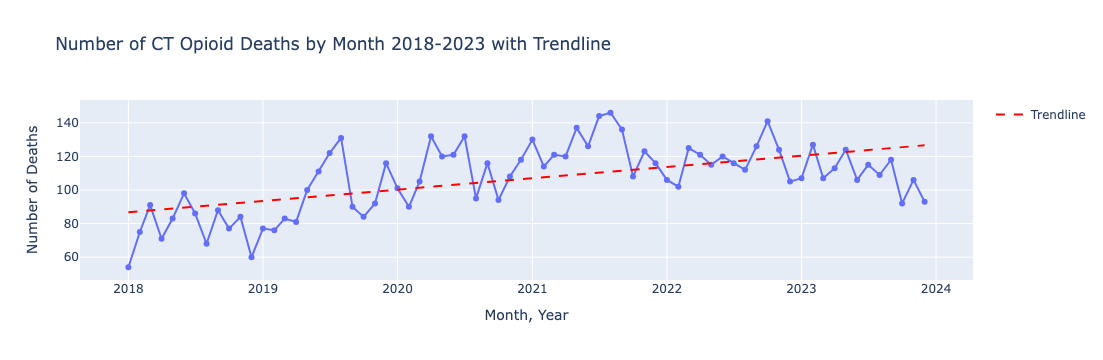

In [60]:
#Plot findings 
import pandas as pd
import numpy as np
import plotly.express as px

# Get Month-level Date data and order chronologically
df_grouped_timeseries["Date"] = pd.to_datetime(df_grouped_timeseries["Month, Year"])
df_grouped_timeseries = df_grouped_timeseries.sort_values("Date")

# Create a trendline using NumPy's polynomial fit
x = np.arange(len(df_grouped_timeseries))
y = df_grouped_timeseries["Number of Incidents"]
trend = np.polyfit(x, y, 1)
trend_fn = np.poly1d(trend)

# Add trendline data to the dataframe
df_grouped_timeseries["Trendline"] = trend_fn(x)

# Create an interactive line chart with hover Legends: # Deaths by Month
fig = px.line(
    df_grouped_timeseries, 
    x="Date", 
    y="Number of Incidents", 
    markers=True, 
    title="Number of CT Opioid Deaths by Month 2018-2023 with Trendline",
    labels={"Date": "Month, Year", "Number of Incidents": "Number of Deaths"},
    hover_data={"Date": True, "Number of Incidents": True}, 
)

# Adding a overlay Trendline of Opioid Deaths over the last 5 years
fig.add_scatter(
    x=df_grouped_timeseries["Date"], 
    y=df_grouped_timeseries["Trendline"], 
    mode="lines", 
    line=dict(dash="dash", color="red"), 
    name="Trendline"
)

fig.show()

## Demographic Profile of Drug Deaths in Connecticut 2018-2023 (Kehleboe)

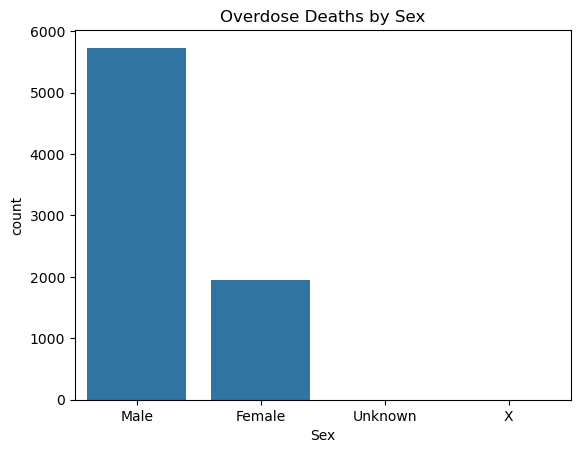

In [61]:
#Demographics
import seaborn as sns
import matplotlib.pyplot as plt

# Sex distribution
sns.countplot(data=opioid_df, x='Sex')
plt.title("Overdose Deaths by Sex")
plt.show()

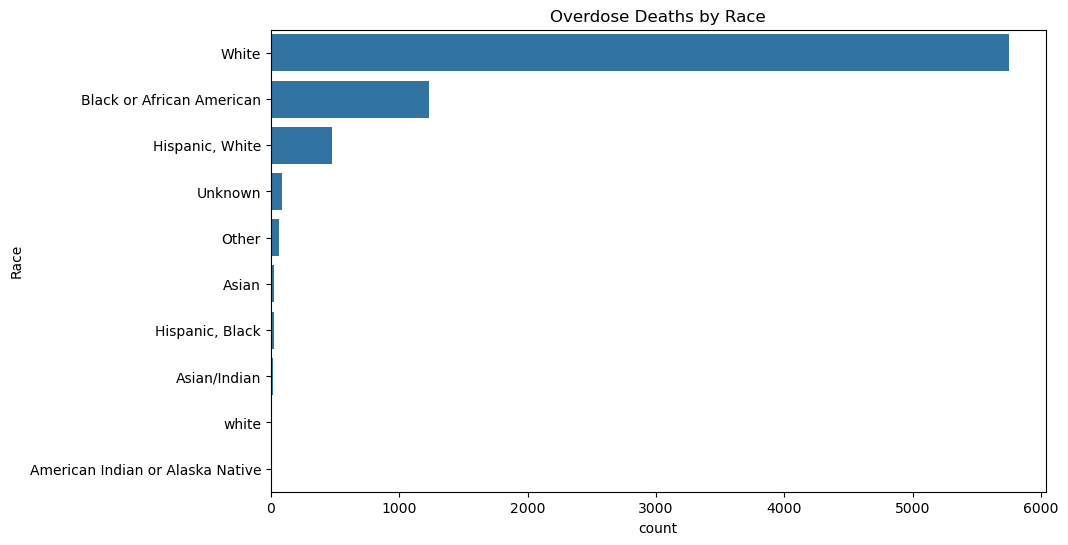

In [62]:
# Race distribution
plt.figure(figsize=(10,6))
sns.countplot(data=opioid_df, y='Race', order=opioid_df['Race'].value_counts().index)
plt.title("Overdose Deaths by Race")
plt.show()

## Deaths By Drug Type in Connecticut 2018-2023 (Carleigh)

In [63]:
#inspect column names
print(opioid_df.columns)

Index(['IncidentID', 'DateReported', 'Sex', 'Race', 'Age', 'InjuryPlace',
       'InjuryCity', 'InjuryCounty', 'InjuryState', 'InjuryZip', 'Heroin',
       'Cocaine', 'Fetanyl', 'Fentanyl Analogue', 'Oxycodone', 'Oxymorphone',
       'Ethanol', 'Hydrocodone', 'Benzodiazepines', 'Methadone',
       'Meth/Amphetamine', 'Tramadol', 'Hydromorphone',
       'Morphine (not heroin)', 'Other', 'Unnamed: 25', 'Unnamed: 26'],
      dtype='object')


In [50]:
#filter certain columns that would apply to my visualization: # deaths by drug type
columns_to_filter = ["Heroin", "Cocaine", "Fentanyl", "Fentanyl Analogue", "Oxycodone", "Oxymorphone", "Ethanol", "Hydrocodone", "Benzodiazepines", "Methadone", "Meth/Amphetamine", "Tramadol", "Hydromorphone", "Morphine (not heroin)", "Other"]

#create a loop for existing columns and the columns we want to filter
existing_columns = [col for col in columns_to_filter if col in opioid_df.columns]

#create a dataframe from the filtered columns
carleigh_filtered_df = opioid_df[existing_columns]

In [31]:
deaths_by_drug = carleigh_filtered_df[existing_columns].sum().reset_index()
deaths_by_drug.columns = ['Drug', 'Number_of_Deaths']

In [32]:
#sort from highest to lowest # of deaths
deaths_by_drug = deaths_by_drug.sort_values(by='Number_of_Deaths', ascending=False)

In [33]:
from bokeh.io import output_file, show
from bokeh.plotting import figure
from bokeh.models import ColumnDataSource, HoverTool

# Step 2: Prepare the Bokeh data source
source = ColumnDataSource(deaths_by_drug)

# Step 3: Create a figure
p = figure(
    x_range=deaths_by_drug['Drug'], 
    title="Number of Deaths by Drug Type in Connecticut 2018-2023",
    toolbar_location=None, 
    tools="hover", 
    tooltips="@Drug: @Number_of_Deaths",
    width=900,
    height=500
)

# Step 4: Create a bar chart
p.vbar(x='Drug', top='Number_of_Deaths', width=0.6, source=source, color='darkviolet')

# Step 5: Style the plot
p.xgrid.grid_line_color = None
p.y_range.start = 0
p.xaxis.major_label_orientation = 1.2  # tilt x-axis labels for readability

# Step 6: Show the interactive chart
show(p)

In [ ]:
#filter certain columns that would apply to my visualization: # deaths by drug type
#opioid_df = opioid_df.drop(columns=["IncidentID", "InjuryCity", "InjuryCounty", "InjuryState", "InjuryState, "Unnamed: 25", "Unnamed: 26", "DateReported"])

## A Geographic Analysis of Drug-Related Deaths in Connecticut (Marina)

## KMeans Clustering

In [34]:
opioid_df = opioid_df.drop(columns=["Age", "IncidentID", "InjuryCity", "InjuryZip", "Other", "InjuryCounty", "InjuryState", "Unnamed: 25", "Unnamed: 26", "DateReported"])

In [35]:
print(opioid_df.dtypes)

Sex                      object
Race                     object
InjuryPlace              object
Heroin                    int64
Cocaine                   int64
Fetanyl                   int64
Fentanyl Analogue         int64
Oxycodone                 int64
Oxymorphone               int64
Ethanol                   int64
Hydrocodone               int64
Benzodiazepines           int64
Methadone                 int64
Meth/Amphetamine          int64
Tramadol                  int64
Hydromorphone             int64
Morphine (not heroin)     int64
dtype: object


In [36]:
#count how many places there are in InjuryPlace
injury_place_counts = opioid_df["InjuryPlace"].value_counts()
injury_place_counts

InjuryPlace
Residence                 3263
Home                      1781
Other                      523
Other Specified Place      367
Unknown                    363
                          ... 
Railroad Track               1
River, Stream or Canal       1
Relative's Home              1
residence                    1
Motel/Hotel                  1
Name: count, Length: 87, dtype: int64

In [37]:
#consolidating the InjuryPlace column with a threshhold
injury_place_to_replace = injury_place_counts[injury_place_counts < 100].index

for injury in injury_place_to_replace:
    opioid_df["InjuryPlace"] = opioid_df["InjuryPlace"] .replace(injury, "Other")

In [38]:
#one-hot encode selected columns
opioid_dummies = pd.get_dummies(opioid_df)

In [39]:
# sanity check
print(opioid_dummies.dtypes)

Heroin                                   int64
Cocaine                                  int64
Fetanyl                                  int64
Fentanyl Analogue                        int64
Oxycodone                                int64
Oxymorphone                              int64
Ethanol                                  int64
Hydrocodone                              int64
Benzodiazepines                          int64
Methadone                                int64
Meth/Amphetamine                         int64
Tramadol                                 int64
Hydromorphone                            int64
Morphine (not heroin)                    int64
Sex_Female                                bool
Sex_Male                                  bool
Sex_Unknown                               bool
Sex_X                                     bool
Race_American Indian or Alaska Native     bool
Race_Asian                                bool
Race_Asian/Indian                         bool
Race_Black or

In [40]:
# Create a list of all Boolean Columns (demographics)
demographic_columns = opioid_dummies.select_dtypes(include=bool).columns.tolist()

# Also get all Drug Type columns into a list for later analysis reference
drug_columns = opioid_dummies.select_dtypes(include=int).columns.tolist()

In [41]:
#Transform Boolean values to Binary for shares by cluster
opioid_dummies[demographic_columns] = opioid_dummies[demographic_columns].astype(int)
opioid_dummies.head()

,Heroin,Cocaine,Fetanyl,Fentanyl Analogue,Oxycodone,Oxymorphone,Ethanol,Hydrocodone,Benzodiazepines,Methadone,...,Race_white,InjuryPlace_Home,InjuryPlace_Hotel or Motel,InjuryPlace_House,InjuryPlace_In Vehicle,InjuryPlace_Other,InjuryPlace_Other Specified Place,InjuryPlace_Residence,InjuryPlace_Unknown,InjuryPlace_Unspecified Place
0,1,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0,1,0,0,1,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
2,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0,1,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [42]:
# Create a a list to store inertia values
inertia = []

# Create a a list to store the values of k
k = list(range(1, 11))

In [43]:
# Create a for-loop where each value of k is evaluated using the K-means algorithm
# Fit the model using the spread_df DataFrame
# Append the value of the computed inertia from the `inertia_` attribute of the KMeans model instance
for i in k:
    k_model = KMeans(n_clusters=i, random_state=1)
    k_model.fit(opioid_dummies)
    inertia.append(k_model.inertia_)

In [44]:
# Create a Dictionary that holds the list values for k and inertia
elbow_data = {"k": k, "inertia": inertia}

# Create a DataFrame using the elbow_data Dictionary
df_elbow = pd.DataFrame(elbow_data)

# Review the DataFrame
df_elbow.head()

,k,inertia
0,1,21521.271709
1,2,18570.362040
2,3,16902.492602
3,4,15744.555164
4,5,14935.303201


In [45]:
# Plot the DataFrame
df_elbow.hvplot.line(
    x="k",
    y="inertia",
    title="Elbow Curve",
    xticks=k
)

:Curve   [k]   (inertia)

In [46]:
pd.set_option('display.max_columns', None)

In [47]:
#define the model with 7 clusters
model = KMeans(n_clusters=7, random_state=3)

#fit the model
model.fit(opioid_dummies)

#make predictions
k_7 = model.predict(opioid_dummies)

#create a copy of the preprocessed data
opioid_predictions_df = opioid_dummies.copy()

#add a class column with the labels
opioid_predictions_df['cluster'] = k_7

#group the clusters so we can compare/contrast
cluster_0 = opioid_predictions_df[opioid_predictions_df['cluster'] == 0]
cluster_1 = opioid_predictions_df[opioid_predictions_df['cluster'] == 1]
cluster_2 = opioid_predictions_df[opioid_predictions_df['cluster'] == 2]
cluster_3 = opioid_predictions_df[opioid_predictions_df['cluster'] == 3]
cluster_4 = opioid_predictions_df[opioid_predictions_df['cluster'] == 4]
cluster_5 = opioid_predictions_df[opioid_predictions_df['cluster'] == 5]
cluster_6 = opioid_predictions_df[opioid_predictions_df['cluster'] == 6]

In [48]:
cluster_averages_demographics = opioid_predictions_df.groupby('cluster')[demographic_columns].mean()
cluster_averages_demographics = cluster_averages_demographics.style.format("{:.2%}")
cluster_averages_demographics

,Sex_Female,Sex_Male,Sex_Unknown,Sex_X,Race_American Indian or Alaska Native,Race_Asian,Race_Asian/Indian,Race_Black or African American,"Race_Hispanic, Black","Race_Hispanic, White",Race_Other,Race_Unknown,Race_White,Race_white,InjuryPlace_Home,InjuryPlace_Hotel or Motel,InjuryPlace_House,InjuryPlace_In Vehicle,InjuryPlace_Other,InjuryPlace_Other Specified Place,InjuryPlace_Residence,InjuryPlace_Unknown,InjuryPlace_Unspecified Place
cluster,,,,,,,,,,,,,,,,,,,,,,,
0,0.00%,99.78%,0.11%,0.00%,0.00%,0.00%,0.00%,100.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,23.05%,4.61%,1.32%,2.20%,24.26%,5.93%,29.53%,7.24%,1.87%
1,0.00%,99.88%,0.00%,0.00%,0.00%,0.37%,0.25%,0.00%,0.43%,13.87%,0.62%,0.92%,83.54%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,100.00%,0.00%,0.00%
2,0.00%,99.81%,0.09%,0.09%,0.00%,0.37%,0.47%,0.00%,0.00%,0.00%,1.40%,1.21%,96.45%,0.09%,100.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
3,100.00%,0.00%,0.00%,0.00%,0.00%,0.12%,0.23%,11.28%,0.12%,6.28%,0.00%,0.70%,81.28%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,100.00%,0.00%,0.00%
4,0.00%,99.85%,0.00%,0.00%,0.00%,0.00%,0.30%,0.45%,0.00%,4.07%,0.15%,0.45%,94.57%,0.00%,0.00%,6.03%,1.66%,0.75%,2.26%,4.52%,77.22%,6.33%,1.21%
5,99.91%,0.00%,0.00%,0.00%,0.00%,0.74%,0.09%,20.70%,0.18%,1.66%,1.48%,1.29%,73.75%,0.09%,46.21%,6.84%,2.50%,1.39%,25.60%,8.50%,0.00%,6.56%,2.40%
6,0.00%,99.86%,0.00%,0.00%,0.07%,0.34%,0.41%,0.00%,0.82%,10.46%,1.29%,2.58%,84.04%,0.00%,0.00%,11.14%,4.48%,4.35%,51.09%,12.98%,0.00%,12.50%,3.46%


In [49]:
cluster_averages_drugtypes = opioid_predictions_df.groupby('cluster')[drug_columns].mean()
cluster_averages_drugtypes = cluster_averages_drugtypes.style.format("{:.2%}")
cluster_averages_drugtypes

,Heroin,Cocaine,Fetanyl,Fentanyl Analogue,Oxycodone,Oxymorphone,Ethanol,Hydrocodone,Benzodiazepines,Methadone,Meth/Amphetamine,Tramadol,Hydromorphone,Morphine (not heroin)
cluster,,,,,,,,,,,,,,
0,14.93%,55.43%,86.28%,7.57%,6.48%,0.44%,31.28%,0.22%,4.94%,3.95%,3.73%,1.32%,0.55%,1.10%
1,25.15%,35.27%,84.96%,12.58%,5.55%,0.80%,28.05%,0.86%,0.00%,6.23%,4.62%,2.96%,0.74%,3.02%
2,10.36%,44.91%,86.74%,9.43%,15.03%,0.65%,25.02%,0.65%,18.30%,11.02%,5.51%,1.77%,0.65%,0.47%
3,21.86%,33.60%,72.09%,10.35%,9.19%,2.09%,22.33%,1.40%,37.67%,13.84%,6.51%,3.02%,1.51%,2.79%
4,30.77%,25.49%,77.83%,12.67%,12.52%,1.81%,24.13%,1.51%,100.00%,15.69%,9.80%,4.07%,1.06%,3.62%
5,12.11%,51.02%,80.41%,9.70%,12.01%,0.55%,26.62%,0.74%,26.16%,10.26%,7.02%,3.05%,0.92%,1.11%
6,14.54%,50.82%,89.33%,11.28%,8.90%,0.34%,32.81%,0.61%,5.91%,5.98%,4.62%,2.65%,0.48%,2.04%
